# El Cambio de Paradigma
**Objetivo del bloque**: entender por que el paradigma del software tradicional falla ante ciertos problemas
y como identificar el tipo de problema antes de elegir cualquier tecnología.

El error más común al empezar con IA es elegir la herramienta antes de entender el problema.
Este bloque entrena el criterio para reconocer cuando las reglas son suficientes y cuando no lo son.

---

**Estructura del notebook:**
1. Reglas vs Aprendizaje - el experimento mental
2. Demostración: separabilidad lineal vs no lineal
3. Test de programabilidad - 4 preguntas para cualquier problema
4. Sistemas lineales vs no lineales - ejemplos de negocio
5. Variable objetivo - el concepto clave antes de elegir técnica
6. Ejercicio de autoevaluación

In [1]:
# Crear directorio de exportacion de imagenes
import os
os.makedirs('images', exist_ok=True)
print('[OK] Directorio images/ listo')

[OK] Directorio images/ listo


In [2]:
# Setup: preparar entorno
from pathlib import Path
import os

SCRIPTS = Path('..') / 'ejemplos_codigo'
if not SCRIPTS.is_dir():
    raise FileNotFoundError(
        f"No se encuentra '{SCRIPTS.resolve()}'.\n"
        "Ejecuta este notebook desde la carpeta Jupyter_notebooks/"
    )

os.chdir(SCRIPTS)
print(f"[OK] Directorio de scripts: {os.getcwd()}")

%pip install -q scikit-learn matplotlib numpy
%matplotlib inline

[OK] Directorio de scripts: /home/amador/compartido/alh-python/projects/formación_AI_springter/ejemplos_codigo
Note: you may need to restart the kernel to use updated packages.


---
## 1. Reglas vs Aprendizaje

El enfoque clásico de software es: **DATOS + REGLAS escritas por humanos → RESPUESTAS**

El enfoque ML es lo contrario: **DATOS + RESPUESTAS conocidas → REGLAS descubiertas**

El problema no es que las reglas sean malas. Es que hay problemas donde el conocimiento
que necesitamos **no existe en forma de reglas**, porque nadie podría escribirlas aunque quisiera.

Intenta escribir las reglas para distinguir un perro de un gato:

```
REGLA 1: Si tiene hocico largo, es un perro.
 -> Problema: los Pugs tienen el hocico corto.

REGLA 2: Si maúlla, es un gato.
 -> Problema: hay perros que emiten sonidos parecidos a maullar.

REGLA 3: Si pesa más de 5 kilos y tiene orejas caídas...
 -> Problema: hay gatos de más de 5 kilos.
```

Por cada regla que añadíamos, aparece una excepción. El conocimiento que necesitamos
no es verbalizable: vive en la distribución estadística de ejemplos.

**La pregunta que hay que hacerse antes de cualquier proyecto:**
> ¿El conocimiento que necesito existe en forma de reglas que alguien podría escribir?

> **Antes de seguir:** ¿puedes pensar en un proceso de tu trabajo diario donde la respuesta correcta depende de algo que sabrías reconocer pero no sabrías escribir como regla?

<details>
<summary>Orientación para el instructor (desplegar tras la reflexión)</summary>

**Una respuesta madura menciona al menos uno de estos elementos:**
- Un proceso donde la variabilidad de los casos hace que cualquier regla quede incompleta (clasificar emails, priorizar incidencias, valorar una propuesta comercial)
- La expresión "lo sé cuando lo veo" aplicada a alguna tarea concreta del trabajo
- La diferencia entre seguir un protocolo fijo y tomar una decisión con criterio propio

**Si nadie responde, preguntar:**
"¿Cuántas reglas necesitaríais para clasificar automáticamente todos los tickets de soporte de la empresa? ¿Quién las mantendría cuando cambien los productos?"

**Señal de comprensión:**
El alumno distingue entre conocimiento explícito (escribible en código) y conocimiento implícito (aprendido por experiencia). No hace falta que use esa terminología: basta con que el ejemplo que pone no podría resolverse con un `if/else`.

</details>


---
## 2. Demostración: cuando las reglas no bastan

Este script muestra dos problemas de clasificación en 2 dimensiones:

- **Izquierda**: separación trivial. Un umbral simple (`WHERE valor > x`) funciona perfectamente.
- **Derecha**: separación no trivial. Las dos clases están entrelazadas. Ninguna consulta SQL las separa.

Observa como el segundo problema es exactamente el tipo de problema donde necesitas ML.


╔══════════════════════════════════════════════════════════════════╗
║   CLASIFICAR: ¿cuándo basta una regla y cuándo necesitas IA?    ║
╚══════════════════════════════════════════════════════════════════╝

Imagina que tienes que separar dos grupos de clientes.

CASO 1 -  Clientes premium vs. normales
  Los clientes premium gastan más de 10.000 € al año y hacen más
  de 5 pedidos. Cualquier analista puede escribir esto en SQL:

      SELECT * FROM clientes
      WHERE importe_anual > 10000
        AND num_pedidos   > 5

  Una sola condición. Una línea recta en el espacio de datos.
  No necesitas Machine Learning. No necesitas IA.

CASO 2 -  Clientes que van a cancelar vs. los que no
  Tienes frecuencia de login y puntuación NPS de cada cliente.
  ¿Puedes escribir un WHERE que detecte el churn?

      SELECT * FROM clientes
      WHERE sesiones_mes < ???
        AND nps           < ???

  Los signos de interrogación no son pereza: es que NO EXISTE
  ningún umbral simple. Los clientes q

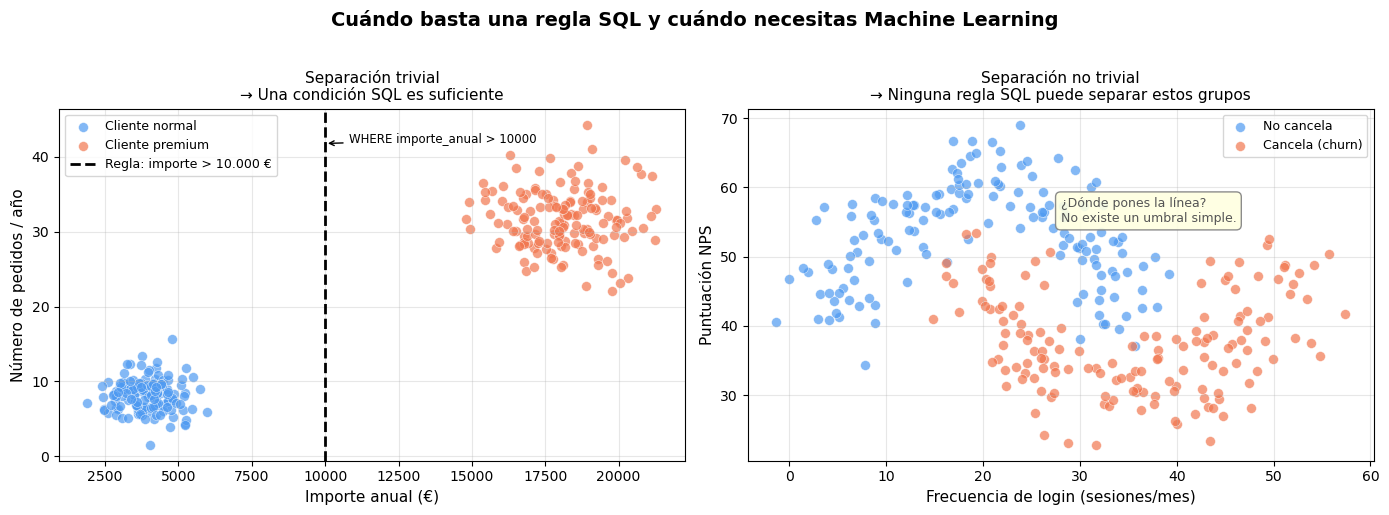


--- Reflexión ---
Panel izquierdo: una sola condición (importe > 10.000 €) separa
perfectamente los grupos. Cualquier analista puede escribir ese WHERE.

Panel derecho: los clientes que cancelan y los que no se MEZCLAN
en el espacio de datos. No existe ningún umbral simple de login o NPS
que los separe. Aquí es donde un modelo de ML aprende la frontera.


<Figure size 640x480 with 0 Axes>

In [3]:
# Separabilidad: SQL vs ML
# Dos nubes de puntos: una separable con una regla, otra no.
%run 00_separabilidad_sql_vs_ml.py

---
## 3. El Test de Programabilidad - 4 preguntas

Antes de pensar en algoritmos, responde estas 4 preguntas sobre tu problema.
La respuesta determina si el problema es **programable** (resoluble con reglas)
o **modelable** (resoluble solo con datos y aprendizaje estadístico).

| # | Pregunta | Si la respuesta es NO... |
|---|---|---|
| 1 | ¿Existe una especificación completa del comportamiento deseado? | No es programable |
| 2 | ¿Los expertos coinciden cuando se les presenta el mismo caso? | Hay ambigüedad, necesitas estadística |
| 3 | ¿Son enumerables todos los casos límite? | Siempre aparecerán casos nuevos |
| 4 | ¿La tolerancia al error es cero? | Si toleras error, ML puede ser mejor |

**Ejemplos contrastados:**

| Problema | Preg.1 | Preg.2 | Preg.3 | Preg.4 | Conclusión |
|---|---|---|---|---|---|
| Calcular impuesto de un pedido | Si | Si | Si | Si | Programable |
| Decidir si un ticket es urgente | No | No | No | No | Modelable (ML) |
| Validar formato de email | Si | Si | Si | Si | Programable |
| Predecir churn de un cliente | No | No | No | No | Modelable (ML) |
| Ordenar una lista de pedidos | Si | Si | Si | Si | Programable |
| Extraer entidades de una RFP | No | No | No | No | Modelable (LLM) |

In [4]:
# Ejercicio interactivo: test de programabilidad
# Modifica el diccionario con tu problema y observa el diagnostico

problema = {
    "descripcion": "Clasificar emails de soporte por departamento",
    "especificacion_completa": False,   # cambia a True/False
    "expertos_coinciden": False,        # cambia a True/False
    "casos_limite_enumerables": False,  # cambia a True/False
    "tolerancia_error_cero": False,     # cambia a True/False
}

# Diagnostico
respuestas = [
    problema["especificacion_completa"],
    problema["expertos_coinciden"],
    problema["casos_limite_enumerables"],
    problema["tolerancia_error_cero"],
]
score_programable = sum(1 for r in respuestas if r)

print(f"Problema: {problema['descripcion']}")
print(f"Score programable: {score_programable}/4")
print()

if score_programable == 4:
    print("[OK] PROGRAMABLE: resuelve con reglas o logica determinista.")
    print("     No necesitas ML. Una funcion, una consulta SQL o una regla basta.")
elif score_programable >= 2:
    print("[!] PARCIALMENTE PROGRAMABLE: considera un enfoque hibrido.")
    print("     Programa lo que puedas con reglas y usa ML solo donde las reglas fallen.")
else:
    print("[X] MODELABLE: necesitas aprendizaje estadistico.")
    print("     El conocimiento no existe en forma de reglas. Usa ML o LLMs.")

Problema: Clasificar emails de soporte por departamento
Score programable: 0/4

[X] MODELABLE: necesitas aprendizaje estadistico.
     El conocimiento no existe en forma de reglas. Usa ML o LLMs.


---
## 4. Sistemas Lineales vs No Lineales

Los sistemas lineales son predecibles: si duplicas la causa, se duplica el efecto.
Se resuelven con fórmulas. Una regla los captura perfectamente.

Los sistemas no lineales son los que encontramos en los negocios reales:
- Añadir un 10% más de coches no genera un 10% más de congestión: puede triplicarla.
- Las ventas de paraguas no son proporcionales a los días de lluvia: hay umbrales, efectos de stock agotado, estacionalidad.
- La demanda del ERP de un cliente no se predice multiplicando usuarios por precio: depende de su ciclo de negocio, sus módulos activos, su historial de incidencias.

Las redes neuronales son **máquinas de aproximar funciones no lineales**.
Esa es su virtud fundamental: pueden aprender las relaciones complejas que ninguna regla podría expresar.

**Implicación directa para la empresa:**
El ERP acumula años de datos históricos. Esos datos capturan la no linealidad del negocio.
Un modelo entrenado sobre ese historial puede predecir mejor que cualquier fórmula.

Pero solo tiene sentido si el problema pasa el test de programabilidad.

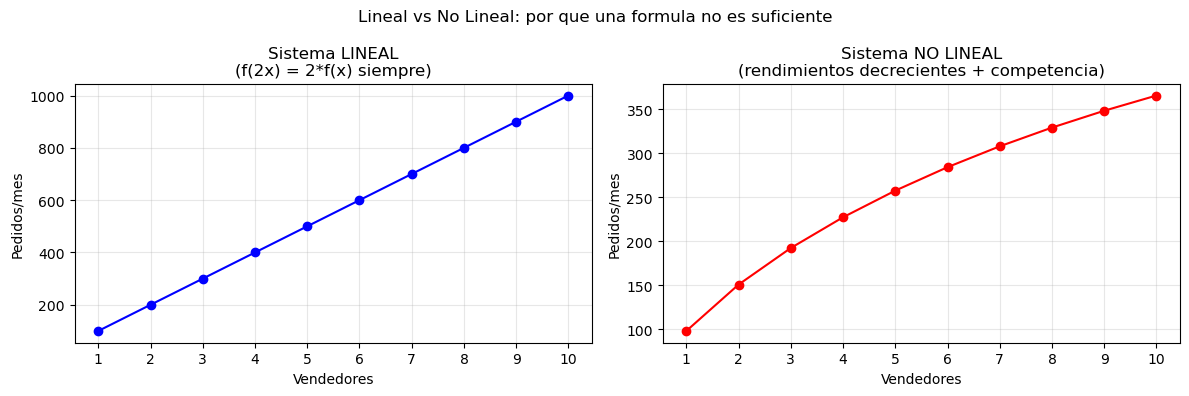

Sistema lineal: duplicar vendedores duplica ventas exactamente.
Sistema no lineal: duplicar vendedores NO duplica ventas.
Para el no lineal, necesitas un modelo que aprenda de los datos historicos.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Sistema lineal: ventas proporcionales al numero de vendedores
vendedores = np.arange(1, 11)
ventas_lineal = vendedores * 100  # 100 pedidos por vendedor, siempre

# Sistema no lineal: ventas con rendimientos decrecientes y curva de aprendizaje
# (los primeros vendedores son los mas productivos; los siguientes compiten entre si)
ventas_no_lineal = 100 * vendedores ** 0.65 * np.exp(-0.02 * vendedores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(vendedores, ventas_lineal, 'b-o')
ax1.set_title('Sistema LINEAL\n(f(2x) = 2*f(x) siempre)')
ax1.set_xlabel('Vendedores')
ax1.set_ylabel('Pedidos/mes')
ax1.set_xticks(vendedores)
ax1.grid(True, alpha=0.3)

ax2.plot(vendedores, ventas_no_lineal, 'r-o')
ax2.set_title('Sistema NO LINEAL\n(rendimientos decrecientes + competencia)')
ax2.set_xlabel('Vendedores')
ax2.set_ylabel('Pedidos/mes')
ax2.set_xticks(vendedores)
ax2.grid(True, alpha=0.3)

plt.suptitle('Lineal vs No Lineal: por que una formula no es suficiente', fontsize=12)
plt.tight_layout()
plt.savefig('images/B01_fig01.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print("Sistema lineal: duplicar vendedores duplica ventas exactamente.")
print("Sistema no lineal: duplicar vendedores NO duplica ventas.")
print("Para el no lineal, necesitas un modelo que aprenda de los datos historicos.")

---
## 5. Variable Objetivo: el concepto previo a cualquier técnica

Antes de elegir un modelo, hay que responder una pregunta:

> **¿Que número concreto queremos que el modelo estime?**

Los sistemas de IA más valiosos no automatizan tareas.
**Estiman propiedades** que permiten tomar mejores decisiones.

- No "gestionan pedidos": estiman la probabilidad de que un pedido llegue tarde.
- No "atienden incidencias": estiman la urgencia de una incidencia.
- No "retienen clientes": estiman la probabilidad de que ese cliente cancele.

La acción la sigue tomando el proceso o la persona.
El modelo aporta la estimación que informa esa acción.

**Ejercicio mental:**
Para cada decisión de negocio que conoces en la empresa,
trata de formularla como una variable numérica específica.
Si no puedes escribirla en una frase, el problema no está definido todavía.

| Decisión de negocio | Variable objetivo (que estima el modelo) |
|---|---|
| ¿Este cliente va a cancelar? | Probabilidad de churn en los próximos 90 días (0-1) |
| ¿Cuanto stock necesito? | Unidades a vender los próximos 7 días (número) |
| ¿Este ticket es urgente? | Probabilidad de incumplir el SLA (0-1) |
| ¿Que precio debo ofertar? | Precio recomendado para esa propuesta (euros) |

---
## 6. Ejercicio: Analiza un problema real de la empresa

Elige un proceso de negocio que conozcas de la empresa y responde estas preguntas.
Escribe tus respuestas en la celda de código como strings.

In [6]:
# Rellena con tu analisis de un proceso de la empresa
analisis = {
    "proceso": "[describe el proceso aqui]",
    "decision_actual": "[que decision toma hoy un humano?]",
    "variable_objetivo": "[que numero concreto podria estimar un modelo?]",
    "tipo_salida": "[probabilidad 0-1 / numero continuo / categoria]",
    "es_programable": "[si/no/parcial - justifica en una frase]",
    "datos_disponibles": "[que datos historicos existen ya en el ERP?]",
}

print("=" * 60)
print("ANALISIS DE PROBLEMA")
print("=" * 60)
for clave, valor in analisis.items():
    print(f"{clave.upper():20s}: {valor}")
print()
print("Siguiente paso: si es modelable, identificar los datos de entrenamiento.")
print("Si es programable, NO uses ML. Escribe la regla.")

ANALISIS DE PROBLEMA
PROCESO             : [describe el proceso aqui]
DECISION_ACTUAL     : [que decision toma hoy un humano?]
VARIABLE_OBJETIVO   : [que numero concreto podria estimar un modelo?]
TIPO_SALIDA         : [probabilidad 0-1 / numero continuo / categoria]
ES_PROGRAMABLE      : [si/no/parcial -  justifica en una frase]
DATOS_DISPONIBLES   : [que datos historicos existen ya en el ERP?]

Siguiente paso: si es modelable, identificar los datos de entrenamiento.
Si es programable, NO uses ML. Escribe la regla.


---
## 7. Ejercicio de Decisión: ¿usarías IA aquí?

Lee el siguiente caso y responde las preguntas. No hay código. Solo razonamiento.

---

### Caso: el sistema de clasificación de tickets en la empresa

El equipo de soporte de un cliente de la empresa lleva tres años clasificando
manualmente los tickets de incidencia en 12 categorías (facturación, configuración,
rendimiento, error crítico, formación...).

El proceso actual: un agente lee el ticket, lo asigna a la categoría correcta
y lo redirige al especialista. Tarda de media 4 minutos por ticket.
El equipo gestiona unos 200 tickets diarios.

**La propuesta sobre la mesa**: entrenar un modelo de clasificación automática
que lea el texto del ticket y lo asigne directamente.
Un consultor externo estima un 85% de precisión en las pruebas iniciales.

---

### Preguntas para reflexionar

**Pregunta 1 - El test de programabilidad**
¿Podrías escribir las reglas de clasificación de forma completa y sin ambigüedades?
Piensa: ¿dos agentes distintos siempre asignarían la misma categoría al mismo ticket?

**Pregunta 2 - El coste del error**
El modelo tiene un 15% de error. ¿Que ocurre cuando clasifica mal?
¿Ese error es tolerable? ¿Es igual de grave para todas las categorías?

**Pregunta 3 - La decisión**
Con lo que sabes ahora: ¿implementarías el modelo directamente, lo usarías como
asistente (el agente decide, el modelo sugiere), o no lo usarías?
Justifica en 3-5 líneas.

**Pregunta 4 - La condición de salida**
Si decides implementarlo: ¿como sabrías si en 6 meses el modelo ha dejado de funcionar bien?
¿Que medida concreta usarías para detectarlo?

---

*Escribe tus respuestas en la celda siguiente.*

### Mis respuestas

**Pregunta 1:**

*(escribe aquí)*

**Pregunta 2:**

*(escribe aquí)*

**Pregunta 3:**

*(escribe aquí)*

**Pregunta 4:**

*(escribe aquí)*

---

<!--
CRITERIOS DE Evaluación (para el instructor)

Pregunta 1 - respuesta esperada:
No es completamente programable. Los agentes no siempre coinciden en tickets ambiguos
(un problema puede ser "configuración" o "formación" según quien lo lea).
Eso indica que el conocimiento es estadístico, no codificable en reglas.

Pregunta 2 - respuesta esperada:
El coste del error no es homogéneo. Clasificar mal un "error crítico" como "formación"
puede retrasar una incidencia grave. El 15% de error puede ser aceptable en promedio
pero inaceptable para las categorías de alta urgencia.
Clave: el alumno debe pensar en coste diferencial por categoría, no en precisión global.

Pregunta 3 - respuesta bien razonada:
"Usaría el modelo como asistente en una primera fase: el modelo sugiere,
el agente confirma o corrige. Esto permite: (a) medir la precisión real en producción,
(b) detectar categorías donde el modelo falla sistemáticamente,
(c) recoger datos de correcciones para mejorar el modelo."
Respuesta incorrecta: implementar directamente sin fase piloto.
También incorrecta: no usarlo porque tiene 15% de error (sin comparar con el error humano).

Pregunta 4 - respuesta esperada:
Medir el porcentaje de reclasificaciones manuales semana a semana.
Si sube por encima del umbral de la fase piloto, el modelo se ha degradado.
También: comparar la distribución de categorías asignadas - si cambia bruscamente,
puede indicar un cambio en el tipo de tickets (drift de datos).
-->


---
## Puntos clave del Bloque 1

1. **Reglas vs Aprendizaje**: cuando el conocimiento no existe en forma de reglas,
   la única opción es que el sistema aprenda de los datos.

2. **Test de programabilidad**: 4 preguntas antes de cualquier decisión técnica.
   Si el problema pasa el test, no necesitas ML.

3. **No linealidad**: los problemas de negocio reales son no lineales.
   Las fórmulas no funcionan. Los modelos aprenden la no linealidad de los datos.

4. **Variable objetivo**: antes de elegir técnica, define que número quieres estimar.
   Si no puedes formularlo como un número, el problema no está definido todavía.

---
**Siguiente bloque**: La Geometría del Aprendizaje - 
como transformar una decisión de negocio en una variable matemática
y que tipos de algoritmos existen para estimarla.